# Monge-gap-regularized kernel regression

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-gap-kernel-regression`. For observations $(x_i,y_i)_{i=1}^n$ on a uniform grid, it computes the convex path

$$
\min_{T\in\mathcal H_k}
\frac1n\sum_{i=1}^n |T(x_i)-y_i|^2
+\lambda\|T\|_{\mathcal H_k}^2
+\gamma\,\mathcal M_{\alpha_n}^{|\cdot|^2}(T),
\qquad
\alpha_n=\frac1n\sum_{i=1}^n\delta_{x_i}.
$$

The two panels contrast a moderate smooth data set with a larger, noisier, multiscale one.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("cvxpy", "cvxpy"),
    ("osqp", "osqp"),
)
ROOT = _OT4ML_STYLE.configure_notebook(packages=_OT4ML_PACKAGES)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
from dataclasses import dataclass
import logging

import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

logging.getLogger("fontTools").setLevel(logging.ERROR)
setup_matplotlib()

NAME = "monge-gap-kernel-regression"
OUT = figure_dir(NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)

## Finite convex reduction

Let $\mathrm K_{ij}=k(x_i,x_j)$. The representer theorem gives
$T_q(\cdot)=\sum_j q_jk(x_j,\cdot)$, so the vector of fitted values is $\mathrm Kq$. For the full quadratic cost $|x-y|^2$, the uniform-grid Monge gap is

$$
\mathcal M_{\alpha_n}^{|\cdot|^2}(T_q)
=\frac{2\Delta}{n}\sum_{i<j}
\big[(\mathrm Kq)_i-(\mathrm Kq)_j\big]_+.
$$

The objective is therefore a convex quadratic plus pairwise hinge penalties. Introducing one nonnegative epigraph variable per pair produces a quadratic program. The hard benchmark replaces the hinges by $(\mathrm Kq)_1\leq\cdots\leq(\mathrm Kq)_n$.

In [3]:
@dataclass(frozen=True)
class RegressionPath:
    """Solutions of one Monge-gap regularization path.

    Attributes:
        penalties: Nonnegative Monge-gap weights.
        coefficients: Kernel coefficients, one row per penalty weight.
        fitted_values: Fitted values at the training inputs.
        gaps: Exact full-quadratic Monge gaps of the fitted values.
        hard_coefficients: Kernel coefficients for the hard monotone fit.
    """

    penalties: np.ndarray
    coefficients: np.ndarray
    fitted_values: np.ndarray
    gaps: np.ndarray
    hard_coefficients: np.ndarray


def gaussian_kernel(
    left_points: np.ndarray,
    right_points: np.ndarray,
    bandwidth: float,
) -> np.ndarray:
    """Evaluate a one-dimensional Gaussian kernel matrix.

    Args:
        left_points: Locations indexing matrix rows.
        right_points: Locations indexing matrix columns.
        bandwidth: Strictly positive Gaussian bandwidth.

    Returns:
        Matrix whose ``(i, j)`` entry is
        ``exp(-(left_points[i]-right_points[j])**2/(2*bandwidth**2))``.

    Raises:
        ValueError: If the bandwidth is nonpositive or an input is not a
            one-dimensional finite array.
    """
    left_points = np.asarray(left_points, dtype=float)
    right_points = np.asarray(right_points, dtype=float)
    if left_points.ndim != 1 or right_points.ndim != 1:
        raise ValueError("Kernel locations must be one-dimensional arrays.")
    if not np.all(np.isfinite(left_points)) or not np.all(np.isfinite(right_points)):
        raise ValueError("Kernel locations must be finite.")
    if bandwidth <= 0.0:
        raise ValueError("The Gaussian bandwidth must be positive.")
    squared_distances = (left_points[:, None] - right_points[None, :]) ** 2
    return np.exp(-squared_distances / (2.0 * bandwidth**2))


def quadratic_monge_gap(inputs: np.ndarray, values: np.ndarray) -> float:
    """Evaluate the empirical Monge gap for the cost ``|x-y|^2``.

    Args:
        inputs: Strictly increasing, equally weighted source locations.
        values: Candidate map values at the source locations.

    Returns:
        The exact gap between the graph cost and the increasing assignment
        cost. The returned normalization matches the book's unhalved cost.

    Raises:
        ValueError: If the arrays have incompatible shapes or the inputs are
            not strictly increasing.
    """
    inputs = np.asarray(inputs, dtype=float)
    values = np.asarray(values, dtype=float)
    if inputs.ndim != 1 or values.shape != inputs.shape:
        raise ValueError("Inputs and values must be one-dimensional arrays of equal size.")
    if np.any(np.diff(inputs) <= 0.0):
        raise ValueError("Source locations must be strictly increasing.")
    return float(2.0 * (inputs @ np.sort(values) - inputs @ values) / inputs.size)

## Solving the path

The zero-penalty endpoint is ordinary kernel ridge regression and is solved in closed form. Positive penalties share one CVXPY problem and are visited from small to large $\gamma$, so OSQP can warm-start from the preceding solution. A separate constrained problem computes the hard monotone endpoint.

In [4]:
def solve_regression_path(
    inputs: np.ndarray,
    observations: np.ndarray,
    *,
    bandwidth: float,
    ridge: float,
    penalties: np.ndarray,
) -> RegressionPath:
    """Solve penalized and hard-monotone Gaussian-kernel regressions.

    Args:
        inputs: Equally spaced, strictly increasing training inputs.
        observations: Scalar responses at the training inputs.
        bandwidth: Positive Gaussian-kernel bandwidth.
        ridge: Positive squared-RKHS-norm weight.
        penalties: Strictly increasing nonnegative Monge-gap weights starting
            at zero.

    Returns:
        Kernel coefficients, fitted values, exact gaps, and the hard-monotone
        benchmark.

    Raises:
        ValueError: If an input fails validation.
        RuntimeError: If a convex subproblem is not solved to acceptable
            accuracy or the final path endpoint remains materially nonmonotone.
    """
    inputs = np.asarray(inputs, dtype=float)
    observations = np.asarray(observations, dtype=float)
    penalties = np.asarray(penalties, dtype=float)
    if inputs.ndim != 1 or observations.shape != inputs.shape:
        raise ValueError("Inputs and observations must have the same vector shape.")
    spacings = np.diff(inputs)
    if np.any(spacings <= 0.0) or not np.allclose(spacings, spacings[0]):
        raise ValueError("The inversion formula requires a strictly increasing uniform grid.")
    if ridge <= 0.0:
        raise ValueError("The RKHS regularization weight must be positive.")
    if penalties.size < 2 or penalties[0] != 0.0 or np.any(np.diff(penalties) <= 0.0):
        raise ValueError("Penalties must increase strictly from zero.")

    sample_count = inputs.size
    grid_step = float(spacings[0])
    gram = gaussian_kernel(inputs, inputs, bandwidth)
    # A small diagonal jitter stabilizes the dense Gaussian Gram matrix.
    gram = gram + 1.0e-3 * np.eye(sample_count)
    pair_indices = np.array(
        [(i, j) for i in range(sample_count) for j in range(i + 1, sample_count)],
        dtype=int,
    )

    # Ordinary kernel ridge regression: (K + n lambda I) q = y.
    initial_coefficients = np.linalg.solve(
        gram + sample_count * ridge * np.eye(sample_count),
        observations,
    )
    coefficient_path = [initial_coefficients]

    coefficients = cp.Variable(sample_count)
    fitted = gram @ coefficients
    slacks = cp.Variable(pair_indices.shape[0], nonneg=True)
    penalty_parameter = cp.Parameter(nonneg=True)
    constraints = [
        slacks >= fitted[pair_indices[:, 0]] - fitted[pair_indices[:, 1]]
    ]
    gap_epigraph = 2.0 * grid_step * cp.sum(slacks) / sample_count
    objective = cp.Minimize(
        cp.sum_squares(fitted - observations)
        + sample_count * ridge * cp.quad_form(coefficients, cp.psd_wrap(gram))
        + sample_count * penalty_parameter * gap_epigraph
    )
    problem = cp.Problem(objective, constraints)

    coefficients.value = initial_coefficients
    for penalty in penalties[1:]:
        penalty_parameter.value = float(penalty)
        problem.solve(
            solver="OSQP",
            eps_abs=1.0e-6,
            eps_rel=1.0e-6,
            max_iter=120_000,
            polishing=True,
            warm_start=True,
            verbose=False,
        )
        if problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
            raise RuntimeError(f"The QP failed for gamma={penalty:g}: {problem.status}.")
        coefficient_path.append(np.asarray(coefficients.value).ravel().copy())

    hard_coefficients = cp.Variable(sample_count)
    hard_fitted = gram @ hard_coefficients
    hard_problem = cp.Problem(
        cp.Minimize(
            cp.sum_squares(hard_fitted - observations)
            + sample_count * ridge * cp.quad_form(hard_coefficients, cp.psd_wrap(gram))
        ),
        [hard_fitted[1:] >= hard_fitted[:-1]],
    )
    hard_problem.solve(
        solver="OSQP",
        eps_abs=1.0e-7,
        eps_rel=1.0e-7,
        max_iter=120_000,
        polishing=True,
        verbose=False,
    )
    if hard_problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
        raise RuntimeError(f"The hard-monotone QP failed: {hard_problem.status}.")

    coefficient_matrix = np.vstack(coefficient_path)
    fitted_matrix = coefficient_matrix @ gram
    gaps = np.array(
        [quadratic_monge_gap(inputs, values) for values in fitted_matrix]
    )
    if gaps[-1] > 1.0e-4:
        raise RuntimeError(
            "Increase the largest penalty: the last fit still has Monge gap "
            f"{gaps[-1]:.3e}."
        )
    return RegressionPath(
        penalties=penalties,
        coefficients=coefficient_matrix,
        fitted_values=fitted_matrix,
        gaps=gaps,
        hard_coefficients=np.asarray(hard_coefficients.value).ravel(),
    )

## Two reproducible experiments

The first data set is the original smooth oscillatory example. The second has $95$ observations, a higher-frequency signal, and stronger additive Gaussian noise. Both use the same normalized penalty values
$\gamma\in\{0,0.1,0.3,0.7,2.5\}$; only the Gaussian bandwidth and mild RKHS ridge weight are adapted to sample resolution.

In [5]:
PENALTIES = np.array([0.0, 0.1, 0.3, 0.7, 2.5])

rng_a = np.random.default_rng(17)
inputs_a = np.linspace(-2.5, 2.5, 55)

def signal_a(points):
    """Return the smooth generating signal for the first experiment."""
    points = np.asarray(points)
    return 0.50 * points + 1.05 * np.sin(2.15 * points)

observations_a = signal_a(inputs_a) + 0.16 * rng_a.normal(size=inputs_a.size)
path_a = solve_regression_path(
    inputs_a,
    observations_a,
    bandwidth=0.62,
    ridge=0.08 / inputs_a.size,
    penalties=PENALTIES,
)

rng_b = np.random.default_rng(91)
inputs_b = np.linspace(-3.0, 3.0, 95)

def signal_b(points):
    """Return the multiscale generating signal for the second experiment."""
    points = np.asarray(points)
    return (
        0.34 * points
        + 0.70 * np.sin(1.55 * points + 0.25)
        + 0.32 * np.sin(3.75 * points - 0.45)
        + 0.13 * np.cos(6.40 * points + 0.30)
    )

observations_b = signal_b(inputs_b) + 0.21 * rng_b.normal(size=inputs_b.size)
path_b = solve_regression_path(
    inputs_b,
    observations_b,
    bandwidth=0.48,
    ridge=0.11 / inputs_b.size,
    penalties=PENALTIES,
)

print("final gaps:", f"{path_a.gaps[-1]:.3e}", f"{path_b.gaps[-1]:.3e}")

final gaps: 5.436e-07 4.751e-06


## Kernel regression paths

Each kernel expansion is evaluated on a fine grid rather than connected only at its training values. Blue is ordinary kernel ridge regression, colors move toward red as $\gamma$ increases, and black dashes show the independently solved hard monotone fit. The faint dashed curve is the noise-free generating function.

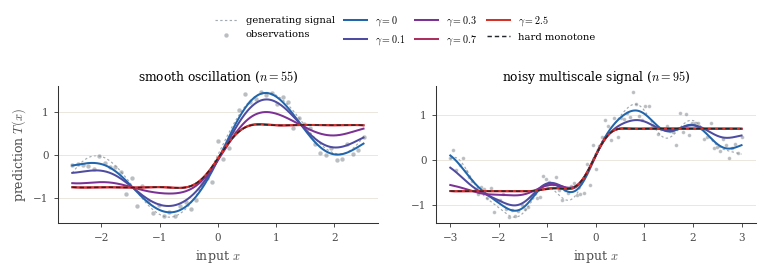

wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/monge-gap-kernel-regression/paths.pdf
thumbnail /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/monge-gap-kernel-regression.png


In [6]:
def evaluate_kernel_expansion(
    evaluation_points: np.ndarray,
    inputs: np.ndarray,
    coefficients: np.ndarray,
    bandwidth: float,
) -> np.ndarray:
    """Evaluate one or several Gaussian-kernel expansions.

    Args:
        evaluation_points: Locations at which to evaluate the functions.
        inputs: Kernel centers used by the expansions.
        coefficients: One coefficient vector or a matrix with one expansion
            per row.
        bandwidth: Gaussian-kernel bandwidth used during fitting.

    Returns:
        Values with one row per coefficient vector and one column per
        evaluation point.
    """
    coefficient_matrix = np.atleast_2d(np.asarray(coefficients, dtype=float))
    cross_gram = gaussian_kernel(evaluation_points, inputs, bandwidth)
    return coefficient_matrix @ cross_gram.T


def style_regression_axis(axis: plt.Axes) -> None:
    """Apply the common compact style to one regression panel."""
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", color=LIGHT_GRAY, linewidth=0.55, alpha=0.68)
    axis.tick_params(colors=GRAY, labelsize=7.5)
    axis.xaxis.label.set_color(GRAY)
    axis.yaxis.label.set_color(GRAY)


color_map = LinearSegmentedColormap.from_list(
    "monge_path",
    [BLUE, VIOLET, RED],
)
path_colors = [color_map(value) for value in np.linspace(0.0, 1.0, PENALTIES.size)]

fig, axes = plt.subplots(1, 2, figsize=(7.55, 2.75))
experiments = (
    (axes[0], inputs_a, observations_a, signal_a, path_a, 0.62, r"smooth oscillation ($n=55$)"),
    (axes[1], inputs_b, observations_b, signal_b, path_b, 0.48, r"noisy multiscale signal ($n=95$)"),
)

for axis, inputs, observations, signal, path, bandwidth, title in experiments:
    evaluation_grid = np.linspace(inputs[0], inputs[-1], 600)
    path_values = evaluate_kernel_expansion(
        evaluation_grid,
        inputs,
        path.coefficients,
        bandwidth,
    )
    hard_values = evaluate_kernel_expansion(
        evaluation_grid,
        inputs,
        path.hard_coefficients,
        bandwidth,
    )[0]

    axis.plot(
        evaluation_grid,
        signal(evaluation_grid),
        color="#a3abb1",
        linewidth=0.85,
        linestyle=(0, (2, 2)),
        label="generating signal",
        zorder=1,
    )
    axis.scatter(
        inputs,
        observations,
        s=11 if inputs.size < 70 else 7,
        color="#7b8389",
        alpha=0.52,
        edgecolor="white",
        linewidth=0.25,
        label="observations",
        zorder=2,
    )
    for penalty, values, color in zip(path.penalties, path_values, path_colors):
        axis.plot(
            evaluation_grid,
            values,
            color=color,
            linewidth=1.45,
            label=rf"$\gamma={penalty:g}$",
            zorder=3,
        )
    axis.plot(
        evaluation_grid,
        hard_values,
        color="#22272b",
        linewidth=1.05,
        linestyle=(0, (3, 2)),
        label="hard monotone",
        zorder=4,
    )
    axis.set_title(title, fontsize=8.8, pad=4.0)
    axis.set_xlabel(r"input $x$")
    style_regression_axis(axis)

axes[0].set_ylabel(r"prediction $T(x)$")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.995),
    ncol=4,
    frameon=False,
    fontsize=7.2,
    handlelength=2.3,
    columnspacing=0.95,
)
fig.subplots_adjust(left=0.07, right=0.995, bottom=0.20, top=0.70, wspace=0.18)

save_pdf(fig, OUT / "paths.pdf", pad_inches=0.03)
fig.savefig(
    THUMBNAIL,
    dpi=240,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)
plt.show()
plt.close(fig)
print(f"wrote {OUT / 'paths.pdf'}")
print(f"thumbnail {THUMBNAIL}")

## Figure preview

The vector PDF above is used by the manuscript. The generated thumbnail below keeps the final two-panel layout visible when browsing the notebook on GitHub.

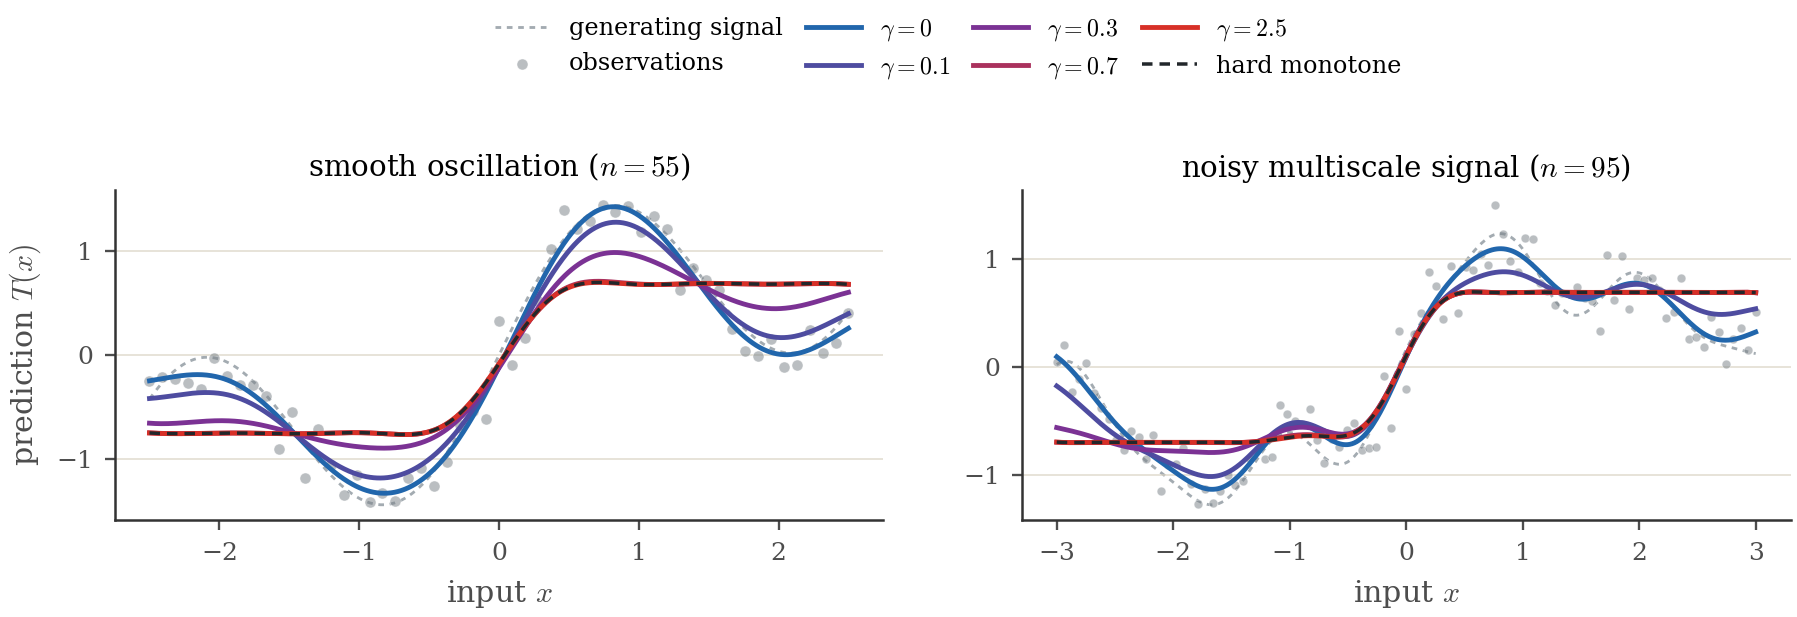

In [7]:
from IPython.display import Image, display

if THUMBNAIL.exists():
    display(Image(filename=str(THUMBNAIL)))
else:
    print("The optional preview is unavailable; execute the rendering cell first.")